In [1]:
from IPython.core.interactiveshell import InteractiveShell

In [2]:
def print_all():
    InteractiveShell.ast_node_interactivity = 'all' 
    return

def print_last():
    InteractiveShell.ast_node_interactivity = 'last_expr' 
    return

In [3]:
Dataset_Path = ".\\data\\chp2\\"

def viewfile(filename, encoding='utf-8'):
    
    with open(filename, 'r', encoding=encoding) as f:
        while True:
            line = f.readline()
            if not line: break
            print(line, end='') 

# 엑셀 파일 다루기
# `xlrd`

## 엑셀 파일 전체 읽기

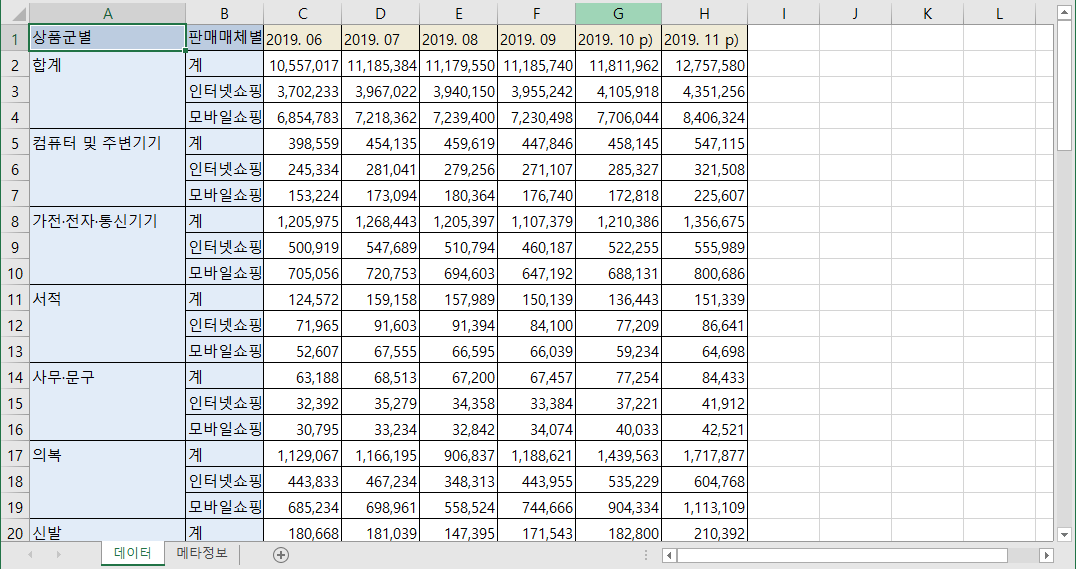

In [ ]:
%conda install xlrd

In [4]:
from xlrd import open_workbook

sample_xlsx = Dataset_Path + '온라인쇼핑몰_판매통계.xls'

book = open_workbook(sample_xlsx)

In [5]:
snames = [s.name for s in book.sheets()]
snames

['데이터', '메타정보']

In [6]:
for s in book.sheets():
    print("{}: ({}, {})".format(s.name, s.nrows, s.ncols))

데이터: (73, 8)
메타정보: (9, 2)


### 전체 내용 표시해보기

In [7]:
for s in book.sheets():  
    print('Sheet:',s.name)
    for row in range(s.nrows):
        values = []
        for col in range(s.ncols):
            values.append(str(s.cell(row,col).value))
        print(','.join(values))

Sheet: 데이터
상품군별,판매매체별,2019. 06,2019. 07,2019. 08,2019. 09,2019. 10 p),2019. 11 p)
합계,계,10557017.0,11185384.0,11179550.0,11185740.0,11811962.0,12757580.0
,인터넷쇼핑,3702233.0,3967022.0,3940150.0,3955242.0,4105918.0,4351256.0
,모바일쇼핑,6854783.0,7218362.0,7239400.0,7230498.0,7706044.0,8406324.0
컴퓨터 및 주변기기,계,398559.0,454135.0,459619.0,447846.0,458145.0,547115.0
,인터넷쇼핑,245334.0,281041.0,279256.0,271107.0,285327.0,321508.0
,모바일쇼핑,153224.0,173094.0,180364.0,176740.0,172818.0,225607.0
가전·전자·통신기기,계,1205975.0,1268443.0,1205397.0,1107379.0,1210386.0,1356675.0
,인터넷쇼핑,500919.0,547689.0,510794.0,460187.0,522255.0,555989.0
,모바일쇼핑,705056.0,720753.0,694603.0,647192.0,688131.0,800686.0
서적,계,124572.0,159158.0,157989.0,150139.0,136443.0,151339.0
,인터넷쇼핑,71965.0,91603.0,91394.0,84100.0,77209.0,86641.0
,모바일쇼핑,52607.0,67555.0,66595.0,66039.0,59234.0,64698.0
사무·문구,계,63188.0,68513.0,67200.0,67457.0,77254.0,84433.0
,인터넷쇼핑,32392.0,35279.0,34358.0,33384.0,37221.0,41912.0
,모바일쇼핑,30795.0,33234.0,32842.0,34074.0,40033.0,42

## Book 들여다 보기

In [8]:
from xlrd import open_workbook

book = open_workbook(sample_xlsx)

print('시트 개수:{}'.format(book.nsheets))

for sheet_index in range(book.nsheets):
    print('시트 번호 {}: {}'.format(sheet_index, book.sheet_by_index(sheet_index)))

print('시트 List = {}'.format(book.sheet_names()))
for sheet_name in book.sheet_names():
    print('시트 {}: {}'.format(sheet_name, book.sheet_by_name(sheet_name)))
    
print('모든 시트:')
for sheet in book.sheets():
    print(sheet)

시트 개수:2
시트 번호 0: Sheet  0:<데이터>
시트 번호 1: Sheet  1:<메타정보>
시트 List = ['데이터', '메타정보']
시트 데이터: Sheet  0:<데이터>
시트 메타정보: Sheet  1:<메타정보>
모든 시트:
Sheet  0:<데이터>
Sheet  1:<메타정보>


In [9]:
book

## Sheet 들여다 보기

In [10]:
for s in book.sheets():
    print("{}: ({}, {})".format(s.name, s.nrows, s.ncols))

데이터: (73, 8)
메타정보: (9, 2)


In [11]:
from xlrd import open_workbook, cellname

book = open_workbook(sample_xlsx)
sheet = book.sheet_by_index(0)  # 첫번째 sheet로 작업
print("====================================")
print("시 트  명: {}".format(sheet.name))
print("시트 차원: ({}, {})".format(sheet.nrows, sheet.ncols))
print("------------------------------------")
print("셀 name   셀 value")
print("------------------------------------")

for row in range(sheet.nrows):
    for col in range(sheet.ncols):
        print('{}        {}'.format(cellname(row, col), sheet.cell(row,col).value))        

시 트  명: 데이터
시트 차원: (73, 8)
------------------------------------
셀 name   셀 value
------------------------------------
A1        상품군별
B1        판매매체별
C1        2019. 06
D1        2019. 07
E1        2019. 08
F1        2019. 09
G1        2019. 10 p)
H1        2019. 11 p)
A2        합계
B2        계
C2        10557017.0
D2        11185384.0
E2        11179550.0
F2        11185740.0
G2        11811962.0
H2        12757580.0
A3        
B3        인터넷쇼핑
C3        3702233.0
D3        3967022.0
E3        3940150.0
F3        3955242.0
G3        4105918.0
H3        4351256.0
A4        
B4        모바일쇼핑
C4        6854783.0
D4        7218362.0
E4        7239400.0
F4        7230498.0
G4        7706044.0
H4        8406324.0
A5        컴퓨터 및 주변기기
B5        계
C5        398559.0
D5        454135.0
E5        459619.0
F5        447846.0
G5        458145.0
H5        547115.0
A6        
B6        인터넷쇼핑
C6        245334.0
D6        281041.0
E6        279256.0
F6        271107.0
G6        285327.0
H6        321508.

## 특정 Cell 가져오기
* ctype: XL_CELL_TEXT, XL_CELL_NUMBER, XL_CELL_DATE, XL_CELL_BOOLEAN

In [12]:
from xlrd import open_workbook, XL_CELL_TEXT, XL_CELL_NUMBER

book = open_workbook(sample_xlsx)
sheet = book.sheet_by_index(1)
cell = sheet.cell(4,1)
print(cell)
print(cell.value)
print(cell.ctype == XL_CELL_NUMBER)

number:3.0
3.0
True


In [13]:
for i in range(sheet.ncols):
    print(sheet.cell_type(5,i),sheet.cell_value(5,i))

1 ○ 자료다운일자
3 43845.0


## 시트 내용을 훓어보기

In [14]:
from xlrd import open_workbook

book = open_workbook(sample_xlsx)
sheet0 = book.sheet_by_index(0)
sheet1 = book.sheet_by_index(1)

In [15]:
print(sheet0.row(0))
print('-----------------------------------')
print(sheet0.col(0))

[text:'상품군별', text:'판매매체별', text:'2019. 06', text:'2019. 07', text:'2019. 08', text:'2019. 09', text:'2019. 10 p)', text:'2019. 11 p)']
-----------------------------------
[text:'상품군별', text:'합계', text:'', text:'', text:'컴퓨터 및 주변기기', text:'', text:'', text:'가전·전자·통신기기', text:'', text:'', text:'서적', text:'', text:'', text:'사무·문구', text:'', text:'', text:'의복', text:'', text:'', text:'신발', text:'', text:'', text:'가방', text:'', text:'', text:'패션용품 및 액세서리', text:'', text:'', text:'스포츠·레저용품', text:'', text:'', text:'화장품', text:'', text:'', text:'아동·유아용품', text:'', text:'', text:'음·식료품', text:'', text:'', text:'농축수산물', text:'', text:'', text:'생활용품', text:'', text:'', text:'자동차용품', text:'', text:'', text:'가구', text:'', text:'', text:'애완용품', text:'', text:'', text:'여행 및 교통서비스', text:'', text:'', text:'문화 및 레저서비스', text:'', text:'', text:'e쿠폰서비스', text:'', text:'', text:'음식서비스', text:'', text:'', text:'기타서비스', text:'', text:'', text:'기타', text:'', text:'']


### row_slice(rowx, start_colx=0, end_colx=None)
Returns a slice of the `Cell` objects in the given row.

In [16]:
print(sheet0.row_slice(0,1))  # row 0 에서, column 1 에서 끝까지

[text:'판매매체별', text:'2019. 06', text:'2019. 07', text:'2019. 08', text:'2019. 09', text:'2019. 10 p)', text:'2019. 11 p)']


In [17]:
print(sheet0.row_slice(0,1,2))  # row 0에서, column 1에서 column 1까지

[text:'판매매체별']


### row_values(rowx, start_colx=0, end_colx=None)
Returns a slice of the values of the cells in the given row.

In [18]:
print(sheet0.row_values(0,1))

['판매매체별', '2019. 06', '2019. 07', '2019. 08', '2019. 09', '2019. 10 p)', '2019. 11 p)']


In [19]:
print(sheet0.row_values(0,1,2))

['판매매체별']


### row_types(rowx, start_colx=0, end_colx=None)
Returns a slice of the types of the cells in the given row.

In [20]:
print(sheet0.row_types(0,1))
print()
print(sheet0.row_types(0,1,2))

array('B', [1, 1, 1, 1, 1, 1, 1])

array('B', [1])


### col_slice(colx, start_rowx=0, end_rowx=None)
Returns a slice of the `Cell` objects in the given column.

In [21]:
print(sheet1.col_slice(0,1))
print()
print(sheet0.col_slice(0,1,2))

[text:'○ 통계표명', text:'○ 조회기간', text:'○ 출처', text:'○ 수정횟수', text:'○ 자료다운일자', text:'○ 통계표URL', empty:'', text:'○ 단위']

[text:'합계']


### col_values(colx, start_rowx=0, end_rowx=None)
Returns a slice of the values of the cells in the given column.

In [22]:
print(sheet1.col_values(0,1))
print()
print(sheet0.col_values(0,1,2))

['○ 통계표명', '○ 조회기간', '○ 출처', '○ 수정횟수', '○ 자료다운일자', '○ 통계표URL', '', '○ 단위']

['합계']


### col_types(colx, start_rowx=0, end_rowx=None)
Returns a slice of the types of the cells in the given column.

In [23]:
print(sheet1.col_types(0,1))
print()
print(sheet0.col_types(2,1,4))

[1, 1, 1, 1, 1, 1, 0, 1]

[2, 2, 2]


## 유틸리티 함수들

In [24]:
from xlrd import cellname, cellnameabs, colname

print(cellname(0,0),cellname(10,10),cellname(100,100))
print()
print(cellnameabs(3,1),cellnameabs(41,59),cellnameabs(265,358))
print()
print(colname(0),colname(10),colname(100))

A1 K11 CW101

$B$4 $BH$42 $MU$266

A K CW


## 셀 타입 - Date type 다루기

In [25]:
from datetime import date, datetime, time
from xlrd import open_workbook, xldate_as_tuple

book = open_workbook(Dataset_Path+'작업일자표.xls')
sheet = book.sheet_by_index(0)

### xlrd.xldate.xldate_as_tuple(xldate, datemode)
Convert an Excel number (presumed to represent a date, a datetime or a time) into a tuple suitable for feeding to datetime or mx.DateTime constructors.

>**Parameters:**  	
>xldate – The Excel number   
>datemode – 0: 1900-based, 1: 1904-based.

In [26]:
date_value = xldate_as_tuple(sheet.cell(3,2).value, book.datemode)
date_value

(2019, 1, 5, 10, 31, 29)

In [27]:
print(datetime(*date_value))
print()
print(date(*date_value[:3]))

2019-01-05 10:31:29

2019-01-05


In [28]:
datetime_value = xldate_as_tuple(sheet.cell(3,3).value, book.datemode)
print(datetime(*datetime_value))

2019-01-12 06:46:17


In [29]:
time_value = xldate_as_tuple(sheet.cell(3,4).value, book.datemode)
print(time(*time_value[3:]))
print(datetime(*time_value))

05:57:19
2019-01-10 05:57:19


### Empty / Blank
* empty cell: 상수, 수식 및 접두 문자 등이 없는 정말 아무것도 없는 cell
* blank cell: empty cell 이거나, null string 또는 prefix 문자가 있는 cell

In [30]:
from xlrd import open_workbook, empty_cell
book = open_workbook(Dataset_Path + 'types.xls')
sheet = book.sheet_by_index(0)
print(empty_cell.value)

In [31]:
empty = sheet.cell(6,2)
blank = sheet.cell(7,2)
print(empty is blank, empty is empty_cell, blank is empty_cell)

False False False


### [Note] Python special operators: Identity operators

In [32]:
x1 = 5
y1 = 5
x2 = 'Hello'
y2 = 'Hello'
x3 = [1,2,3]
y3 = [1,2,3]

print(x1 is y1)
print(x2 is y2)
print(x3 is y3)

True
True
False


In [33]:
book = open_workbook(Dataset_Path + 'types.xls',formatting_info=True)
sheet = book.sheet_by_index(0)
empty = sheet.cell(6,2)
blank = sheet.cell(7,2)
print(empty.ctype, repr(empty.value))
print(blank.ctype, repr(blank.value))

0 ''
0 ''


### [Note] str() vs repr()

In [34]:
print_all()

f = 1.12345678901234567
id(f)

g = eval(repr(f))
id(g)

f is g

f == g


True

In [35]:
print_last()

In [36]:
from xlrd import open_workbook

def cell_contents(sheet, row_x):
    result = []
    for col_x in range(1, sheet.ncols):
        cell = sheet.cell(row_x, col_x)
        result.append((cell.ctype, cell, cell.value))
    return result

In [37]:
sheet1 = open_workbook(Dataset_Path+'CellTypes.xls').sheet_by_index(0)
print('XL_CELL_TEXT',cell_contents(sheet1,1))  # row1: col2 - col3
print('XL_CELL_NUMBER',cell_contents(sheet1,2))  # row2: col2 - col3
print('XL_CELL_DATE',cell_contents(sheet1,3))
print('XL_CELL_BOOLEAN',cell_contents(sheet1,4))
print('XL_CELL_ERROR',cell_contents(sheet1,5))
print('XL_CELL_BLANK',cell_contents(sheet1,6))
print('XL_CELL_EMPTY',cell_contents(sheet1,7))
print()
sheet2 = open_workbook(Dataset_Path+'CellTypes.xls',formatting_info=True).sheet_by_index(0)
print('XL_CELL_TEXT',cell_contents(sheet2,1))
print('XL_CELL_NUMBER',cell_contents(sheet2,2))
print('XL_CELL_DATE',cell_contents(sheet2,3))
print('XL_CELL_BOOLEAN',cell_contents(sheet2,4))
print('XL_CELL_ERROR',cell_contents(sheet2,5))
print('XL_CELL_BLANK',cell_contents(sheet2,6))
print('XL_CELL_EMPTY',cell_contents(sheet2,7))

XL_CELL_TEXT [(1, text:'텍스트21', '텍스트21'), (1, text:'텍스트22', '텍스트22'), (1, text:'텍스트23', '텍스트23')]
XL_CELL_NUMBER [(2, number:21.0, 21.0), (2, number:22.0, 22.0), (2, number:23.0, 23.0)]
XL_CELL_DATE [(3, xldate:43497.0, 43497.0), (3, xldate:43498.0, 43498.0), (3, xldate:43499.0, 43499.0)]
XL_CELL_BOOLEAN [(4, bool:0, 0), (4, bool:1, 1), (4, bool:1, 1)]
XL_CELL_ERROR [(5, error:0, 0), (5, error:0, 0), (5, error:23, 23)]
XL_CELL_BLANK [(1, text:'', ''), (1, text:'', ''), (0, empty:'', '')]
XL_CELL_EMPTY [(0, empty:'', ''), (0, empty:'', ''), (0, empty:'', '')]

XL_CELL_TEXT [(1, text:'텍스트21' (XF:15), '텍스트21'), (1, text:'텍스트22' (XF:15), '텍스트22'), (1, text:'텍스트23' (XF:15), '텍스트23')]
XL_CELL_NUMBER [(2, number:21.0 (XF:15), 21.0), (2, number:22.0 (XF:15), 22.0), (2, number:23.0 (XF:15), 23.0)]
XL_CELL_DATE [(3, xldate:43497.0 (XF:62), 43497.0), (3, xldate:43498.0 (XF:62), 43498.0), (3, xldate:43499.0 (XF:62), 43499.0)]
XL_CELL_BOOLEAN [(4, bool:0 (XF:15), 0), (4, bool:1 (XF:15), 1), (4, boo

# 통합 문서 만들고 저장하기
# `xlwt`

In [38]:
%conda install xlwt

Solving environment: ...working... done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [39]:
from tempfile import TemporaryFile
from xlwt import Workbook

book = Workbook()
sheet1 = book.add_sheet('Sheet 1')
book.add_sheet('Sheet 2')

In [40]:
sheet1.write(0, 0, 'A1')  # row 0, col 0, label='A1'
sheet1.write(0, 1, 'B1')
row1 = sheet1.row(1)  # row 1(2nd row)
row1.write(0,'A2')  # row 1, col 0, lable='A2'
row1.write(1,'B2')  # row 1, col 1, lable='B2'
sheet1.col(0).width = 10000

In [41]:
sheet2 = book.get_sheet(1)
sheet2.row(0).write(0,'Sheet 2 A1')
sheet2.row(0).write(1,'Sheet 2 B1')
sheet2.flush_row_data()
sheet2.write(1,0,'Sheet 2 A3')
sheet2.col(0).width = 5000
sheet2.col(0).hidden = True

book.save('simple.xls')
book.save(TemporaryFile())

A1	B1
A2	B2
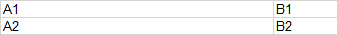

In [44]:
from xlwt import Workbook

book = Workbook()
sheet1 = book.add_sheet('Sheet 1', cell_overwrite_ok=True)
sheet1.write(0,0,'original')
sheet = book.get_sheet(0)
sheet.write(0,0,'new')

In [45]:
sheet2 = book.add_sheet('Sheet 2')
sheet2.write(0,0,'original')
sheet2.write(0,0,'new')

Exception: Attempt to overwrite cell: sheetname='Sheet 2' rowx=0 colx=0

## Cell Types

In [46]:
from datetime import date, time, datetime
from decimal import Decimal
from xlwt import Workbook, Style

wb = Workbook()
ws = wb.add_sheet('Type examples')
ws.row(0).write(0,u'\xa3')
ws.row(0).write(1,'Text')
ws.row(1).write(0,3.1415)
ws.row(1).write(1,15)
ws.row(1).write(2,265)
ws.row(1).write(3,Decimal('3.65'))
ws.row(2).set_cell_number(0,3.1415)
ws.row(2).set_cell_number(1,15)
ws.row(2).set_cell_number(2,265)
ws.row(2).set_cell_number(3,Decimal('3.65'))
ws.row(3).write(0,date(2009,3,18))
ws.row(3).write(1,datetime(2009,3,18,17,0,1))
ws.row(3).write(2,time(17,1))
ws.row(4).set_cell_date(0,date(2009,3,18))
ws.row(4).set_cell_date(1,datetime(2009,3,18,17,0,1))
ws.row(4).set_cell_date(2,time(17,1))
ws.row(5).write(0,False)
ws.row(5).write(1,True)
ws.row(6).set_cell_boolean(0,False)
ws.row(6).set_cell_boolean(1,True)
ws.row(7).set_cell_error(0,0x17)
ws.row(7).set_cell_error(1,'#NULL!')
ws.row(8).write(0,'',Style.easyxf('pattern: pattern solid, fore_colour green;'))
ws.row(8).write(1,None,Style.easyxf('pattern: pattern solid, fore_colour blue;'))
ws.row(9).set_cell_blank(0,Style.easyxf('pattern: pattern solid, fore_colour yellow;'))
ws.row(10).set_cell_mulblanks(5,10,Style.easyxf('pattern: pattern solid, fore_colour red;'))
wb.save(Dataset_Path+'types.xls')

## Styles

### XFStyle – 빨간색, 검은 테두리, Arial 폰트의 Date 셀 만들기

In [47]:
from datetime import date
from xlwt import Workbook, XFStyle, Borders, Pattern, Font

fnt = Font()
fnt.name = 'Arial'

borders = Borders()
borders.left = Borders.THICK
borders.right = Borders.THICK
borders.top = Borders.THICK
borders.bottom = Borders.THICK

pattern = Pattern()
pattern.pattern = Pattern.SOLID_PATTERN
pattern.pattern_fore_colour = 0x0A

style = XFStyle()
style.num_format_str='YYYY-MM-DD'
style.font = fnt
style.borders = borders
style.pattern = pattern

book = Workbook()
sheet = book.add_sheet('A Date')
sheet.write(1,1,date(2009,3,18),style)

book.save(Dataset_Path+'date.xls')

### easyxf – 더 쉬운 XFStyle

In [48]:
from datetime import date
from xlwt import Workbook, easyxf

book = Workbook()
sheet = book.add_sheet('A Date')

sheet.write(1,1,date(2009,3,18),easyxf(
    'font: name Arial;'
    'borders: left thick, right thick, top thick, bottom thick;'
    'pattern: pattern solid, fore_colour red;',
    num_format_str='YYYY-MM-DD'
    ))

book.save(Dataset_Path+'date.xls')

In [49]:
from xlwt import Workbook, easyxf
from xlwt.Utils import rowcol_to_cell

row = easyxf('pattern: pattern solid, fore_colour blue')
col = easyxf('pattern: pattern solid, fore_colour green')
cell = easyxf('pattern: pattern solid, fore_colour red')

book = Workbook()

sheet = book.add_sheet('Precedence')
for i in range(0,10,2):
    sheet.row(i).set_style(row)
for i in range(0,10,2):
    sheet.col(i).set_style(col)
for i in range(10):
    sheet.write(i,i,None,cell)

sheet = book.add_sheet('Hiding')
for rowx in range(10):
    for colx in range(10):
        sheet.write(rowx,colx,rowcol_to_cell(rowx,colx))
for i in range(0,10,2):
    sheet.row(i).hidden = True
    sheet.col(i).hidden = True

sheet = book.add_sheet('Row height and Column width')
for i in range(10):
    sheet.write(0,i,0)
for i in range(10):
    sheet.row(i).set_style(easyxf('font:height '+str(200*i)))
    sheet.col(i).width = 256*i
    
book.save(Dataset_Path+'format_rowscols.xls')